# Introduction aux U-net / *U-net introduction*

Un CNN “classique” résume toute l’image en une prédiction (chien vs. chat). Un U-Net fait l’inverse : il produit une carte par pixel (chat et, où est le chat ?). Pour y arriver sans perdre les détails, il descend (encoder), remonte (decoder) et recâble des informations fines via des skip connections.

*A standard CNN collapses the whole image into one label. A U-Net outputs a label per pixel. It goes down (encoder), goes up (decoder), and reconnects fine details via skip connections*

### Le u-net: “entonnoir” puis “entonnoir inversé” / *"Funnel down, funnel up"*

**Encoder** : Conv → ReLU → MaxPool. Résolution ↓, canaux ↑. On apprend des motifs **Quoi** ? (textures, parties). / *Encoder: resolution ↓, channels ↑ (what).*

**Bottleneck** : champ réceptif large, peu de pixels. / *Bottleneck: large receptive field.*

**Decoder** : UpConv/UpSample → concat avec le skip de même niveau → Conv. On reconstruit **Où ?** (formes, bords). / *Decoder: upsample + skip concat → recover where (edges, shapes).*

### Import

In [9]:
import os, csv, time, random, argparse, warnings
from pathlib import Path
from glob import glob

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as T
from torchvision.datasets import OxfordIIITPet

import torchmetrics
from torchmetrics.classification import BinaryAccuracy
from torchmetrics.segmentation import GeneralizedDiceScore, MeanIoU
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm

warnings.filterwarnings("ignore")

### Prévisualier les images et les masques / *Preview images and masks*

img exists: True | mask exists: True
mask unique: [0 1]


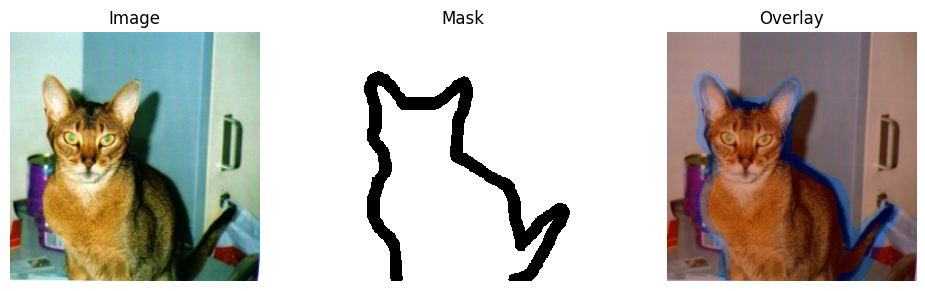

In [10]:
from pathlib import Path
import cv2, numpy as np, matplotlib.pyplot as plt

ROOT = Path("kagglehub/datasets/devdgohil/the-oxfordiiit-pet-dataset/versions/2")

IMG_DIR  = ROOT / "images" / "images"                    # <-- was ROOT/"images"
MASK_DIR = ROOT / "annotations" / "annotations" / "trimaps"
ANN_FILE = ROOT / "annotations" / "annotations" / "trainval.txt"

# Load the list of image stems (e.g., "Abyssinian_100")
with open(ANN_FILE, "r") as f:
    names = [ln.split()[0] for ln in f]

# Try one sample
SIZE = 256
name = names[20]  # change index if you like

img_path  = IMG_DIR  / f"{name}.jpg"
mask_path = MASK_DIR / f"{name}.png"
print("img exists:", img_path.exists(), "| mask exists:", mask_path.exists())
assert img_path.exists(),  f"Missing image: {img_path}"
assert mask_path.exists(), f"Missing mask:  {mask_path}"

# Read + resize
image = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = cv2.resize(image, (SIZE, SIZE), interpolation=cv2.INTER_LINEAR)

mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
mask = cv2.resize(mask, (SIZE, SIZE), interpolation=cv2.INTER_NEAREST)

# raw {1=pet, 2=border, 3=background}  -->  binary {1,1,0}
mask = mask.astype(np.uint8)
mask[mask == 2] = 1
mask[mask == 3] = 0
print("mask unique:", np.unique(mask))  # should be [0 1]

# Display
plt.figure(figsize=(10,3))
plt.subplot(1,3,1); plt.imshow(image); plt.title("Image"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(mask, cmap="gray", vmin=0, vmax=1, interpolation="nearest"); plt.title("Mask"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(image); plt.imshow(mask, cmap="jet", alpha=0.4, vmin=0, vmax=1, interpolation="nearest"); plt.title("Overlay"); plt.axis("off")
plt.tight_layout(); plt.show()


## U-net  

### Description

Le U-Net compresse l’image (encoder), raisonne au "fond" du réseau (bottleneck), puis décompresse (decoder) en rajoutant les détails via des skip connections (concat). Avec 4 niveaux, on divise 4 fois par 2 → il faut que H et W soient multiples de 16 (ex. 256).

 *U-Net compresses (encoder), reasons at the bottom (bottleneck), then decompresses (decoder) while re-injecting detail via skip connections (concat). With 4 levels, we divide 4 times by 2 → H and W must be multiples of 16 (e.g., 256).*

### Hyperparamètres / hyperparameters

In [11]:
# ------------- Repro & device -------------
def seed_all(s=0):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic=True; torch.backends.cudnn.benchmark=False

seed_all(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ------------- Config (EDIT HERE) -------------
IMG_SIZE       = 256               # Try: 128 / 256 / 320 (must be multiple of 16)
BATCH_SIZE     = 8
VAL_SPLIT      = 0.1
TOTAL_EPOCHS   = 15                # Total target epochs for this run
LR             = 1e-3
BASE_CHANNELS  = 32                # Try: 16 / 32 / 64
MILESTONES     = [1, 3, 5, 10, 15] # Snapshots (weights + overlays) at these epochs

SNAP_DIR       = Path("./snapshots_unet_pet")
SNAP_DIR.mkdir(parents=True, exist_ok=True)

# To RESUME from a previous run:
RESUME_CKPT    = Path("./snapshots_unet_pet/last.pt")              # e.g. Path("./snapshots_unet_pet/last.pt") or None

# ------------- Data -------------
tf_img = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),  # [0,1]
])

class PetSegTV(Dataset):
    """
    Oxford-IIIT Pet via torchvision, segmentation trimap {1=pet,2=border,3=bg}.
    We map to a binary "filled" mask: {1,2} -> 1, 3 -> 0.
    """
    def __init__(self, root="./data", split="trainval"):
        self.ds = OxfordIIITPet(root, split=split, target_types=("segmentation",), download=True)
        self.resize_img  = T.Resize((IMG_SIZE, IMG_SIZE))
        self.resize_mask = T.Resize((IMG_SIZE, IMG_SIZE), interpolation=T.InterpolationMode.NEAREST)

    def __len__(self): return len(self.ds)

    def __getitem__(self, i):
        img, mask = self.ds[i]          # PIL RGB, PIL trimap
        img  = self.resize_img(img)
        mask = self.resize_mask(mask)

        img  = tf_img(img)              # [3,H,W] in [0,1]
        m    = np.array(mask, dtype=np.uint8)
        # Trimap -> binary filled
        m[m == 2] = 1   # border -> 1
        m[m == 3] = 0   # background -> 0
        m    = torch.from_numpy(m.astype(np.float32)).unsqueeze(0)  # [1,H,W] in {0,1}
        return img, m

# Split train/val
full = PetSegTV("./data", "trainval")
n = len(full); n_val = int(VAL_SPLIT*n); n_tr = n - n_val
train_set, val_set = torch.utils.data.random_split(full, [n_tr, n_val],
                                                   generator=torch.Generator().manual_seed(0))

# workers=0 for clarity/stability in teaching; increase later if stable
pin = (device.type == "cuda")
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=pin)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=pin)

xb, yb = next(iter(train_loader))
print("Sanity batch:", xb.shape, yb.shape, "mask unique:", torch.unique(yb))


Device: cpu
Sanity batch: torch.Size([8, 3, 256, 256]) torch.Size([8, 1, 256, 256]) mask unique: tensor([0., 1.])


### Fonctions utilitaires / utility functions

In [12]:
# ------------- Snapshot / logging helpers -------------
# Loading : load_snapshot_into_model
# Eval : eval_dice_iou, dice_score
# Visuals : show_grid_img_gt_pred, show_fp_fn
# Snapshots & logs : save_weights_cpu, save_checkpoint, save_history_csv, save_curves
# Training : AMP, early stopping, scheduler (option)

def save_weights_cpu(model, path: Path):
    state = {k: v.detach().cpu() for k, v in model.state_dict().items()}
    torch.save(state, path)

def save_checkpoint(path: Path, epoch: int, model: nn.Module, optimizer, best_val_dice: float):
    ckpt = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_val_dice": best_val_dice,
        "config": {
            "img_size": IMG_SIZE,
            "lr": LR,
            "base_channels": BASE_CHANNELS,
            "total_epochs": TOTAL_EPOCHS,
        }
    }
    torch.save(ckpt, path)

def load_checkpoint(path: Path, model: nn.Module, optimizer):
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    start_epoch = ckpt["epoch"] + 1
    best_val_dice = ckpt.get("best_val_dice", 0.0)
    return start_epoch, best_val_dice

def read_history_csv(path_csv: Path):
    if not path_csv.exists(): return []
    out = []
    with open(path_csv, "r") as f:
        r = csv.DictReader(f)
        for row in r:
            out.append({
                "epoch": int(row["epoch"]),
                "train_loss": float(row["train_loss"]),
                "val_loss": float(row["val_loss"]),
                "val_dice": float(row["val_dice"]),
            })
    return out

def save_history_csv(history, path_csv: Path):
    keys = ["epoch","train_loss","val_loss","val_dice"]
    with open(path_csv, "w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=keys); w.writeheader()
        for h in history: w.writerow({k: h[k] for k in keys})

def save_curves(history, path_png: Path):
    if not history: return
    ep   = [h["epoch"] for h in history]
    tr_l = [h["train_loss"] for h in history]
    va_l = [h["val_loss"] for h in history]
    va_d = [h["val_dice"] for h in history]
    plt.figure(figsize=(7,4))
    plt.plot(ep, tr_l, label="train loss")
    plt.plot(ep, va_l, label="val loss")
    plt.plot(ep, va_d, label="val dice")
    plt.xlabel("epoch"); plt.grid(True); plt.legend(); plt.tight_layout()
    plt.savefig(path_png, dpi=150); plt.close()

@torch.no_grad()
def save_overlay_grid(model, loader, path_png: Path, n=6, thr=0.5):
    model.eval()
    xb, yb = next(iter(loader))
    xb, yb = xb.to(device), yb.to(device)
    logits = model(xb)
    prob   = torch.sigmoid(logits)
    k = min(n, xb.size(0))
    fig, axs = plt.subplots(k, 3, figsize=(9, 3*k))
    for i in range(k):
        img = xb[i].cpu().permute(1,2,0).numpy()
        gt  = yb[i,0].cpu().numpy()
        pr  = (prob[i,0].cpu().numpy() > thr).astype(np.uint8)
        axs[i,0].imshow(img); axs[i,0].set_title("Image"); axs[i,0].axis("off")
        axs[i,1].imshow(gt, cmap="gray", vmin=0, vmax=1, interpolation="nearest"); axs[i,1].set_title("Mask GT"); axs[i,1].axis("off")
        axs[i,2].imshow(img); axs[i,2].imshow(pr, cmap="jet", alpha=0.4, vmin=0, vmax=1, interpolation="nearest"); axs[i,2].set_title("Pred"); axs[i,2].axis("off")
    plt.tight_layout(); plt.savefig(path_png, dpi=150); plt.close()

def load_snapshot_into_model(model, snap_path, device):
    """
    Load a snapshot into `model` and set it to eval().

    Accepts:
        * weights_epoch_X.pth  (raw state_dict)
        * best.pt / last.pt    (checkpoint with 'model_state_dict')
    """
    snap_path = Path(snap_path)
    obj = torch.load(snap_path, map_location=device)

    # Cas checkpoint (best.pt/last.pt) vs state_dict pur (weights_epoch_X.pth)
    if isinstance(obj, dict) and "model_state_dict" in obj:
        state_dict = obj["model_state_dict"]
    else:
        state_dict = obj

    model.load_state_dict(state_dict)
    model.to(device).eval()
    return model

@torch.no_grad()
def eval_dice_iou(model, loader, device, thr=0.5, eps=1e-7, return_per_image=False):
    """
    Evaluate Dice and IoU on a DataLoader.

    Assumptions:
        - logits have shape [B, 1, H, W]
        - y (ground truth) has shape [B, 1, H, W] with values {0,1}
            (if you have a trimap, remap it beforehand)

    Args:
        model: U-Net model
        loader: DataLoader (validation/test)
        device: "cuda" or "cpu"
        thr: threshold to binarize probabilities
        eps: small constant to avoid division by zero
        return_per_image: if True, also returns per-image lists

    Returns:
        (dice, iou) or (dice, iou, dice_list, iou_list)
    """
    model.eval()
    tot_inter = 0.0
    tot_union_d = 0.0
    tot_union_i = 0.0
    dice_list, iou_list = [], []

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        p = (torch.sigmoid(logits) > thr).float()
        y = (yb > 0.5).float()  # au cas où y serait en {0.,1.}

        inter = (p * y).sum(dim=(1, 2, 3))
        union_d = p.sum(dim=(1, 2, 3)) + y.sum(dim=(1, 2, 3))
        union_i = (p + y - p * y).sum(dim=(1, 2, 3))

        if return_per_image:
            dice_list += ((2 * inter + eps) / (union_d + eps)).detach().cpu().tolist()
            iou_list  += ((inter + eps) / (union_i + eps)).detach().cpu().tolist()

        tot_inter   += inter.sum().item()
        tot_union_d += union_d.sum().item()
        tot_union_i += union_i.sum().item()

    if tot_union_d == 0 or tot_union_i == 0:
        out = (float("nan"), float("nan"))
        return (*out, dice_list, iou_list) if return_per_image else out

    dice = (2 * tot_inter + eps) / (tot_union_d + eps)
    iou  = (tot_inter + eps) / (tot_union_i + eps)
    return (dice, iou, dice_list, iou_list) if return_per_image else (dice, iou)

@torch.no_grad()
def show_fp_fn(model, loader, device, thr=0.5, n=4): # call:
    model.eval()
    xb, yb = next(iter(loader)); xb, yb = xb.to(device), yb.to(device)
    p = (torch.sigmoid(model(xb)) > thr).float()
    k = min(n, xb.size(0))
    fig, axs = plt.subplots(k, 2, figsize=(6, 3*k))
    for i in range(k):
        img = xb[i].cpu().permute(1,2,0).numpy().clip(0,1)
        gt  = yb[i,0].cpu().numpy()
        pr  = p[i,0].cpu().numpy()
        fp = (pr==1)&(gt==0)  # rouge
        fn = (pr==0)&(gt==1)  # bleu
        overlay = img.copy()
        overlay[fp] = [1,0,0]; overlay[fn] = [0,0,1]
        axs[i,0].imshow(img);     axs[i,0].set_title("Image"); axs[i,0].axis("off")
        axs[i,1].imshow(overlay); axs[i,1].set_title("FP rouge / FN bleu"); axs[i,1].axis("off")
    plt.tight_layout(); plt.show()

### Définition de l'architecture U-net et entraînement / *Definition of U-net architecture and training*

Input (H×W, C=3).

  └─ Down1:  H/2,  base  
  └─ Down2:  H/4,  2*base  
  └─ Down3:  H/8,  4*base  
  └─ Down4:  H/16, 8*base  
  └─ Bottleneck:   16*base  
  ┌─ Up4  (concat with Down4) → 8*base  
  ┌─ Up3  (concat with Down3) → 4*base  
  ┌─ Up2  (concat with Down2) → 2*base  
  ┌─ Up1  (concat with Down1) → base  
  
Output logits (H×W, 1)  

In [13]:
# =============================
# U-Net minimal + snapshots + resume
# =============================

# ------------- U-Net (4 levels) -------------
class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)

class Down(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.conv = DoubleConv(in_c, out_c)
    def forward(self, x): return self.conv(self.pool(x))

class Up(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.up   = nn.ConvTranspose2d(in_c, in_c // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_c, out_c)
    def forward(self, x, skip):
        x = self.up(x)
        # Optional tiny center-crop if odd sizes cause 1px mismatch
        if x.shape[-2:] != skip.shape[-2:]:
            dh = skip.shape[-2] - x.shape[-2]; dw = skip.shape[-1] - x.shape[-1]
            skip = skip[:, :, dh//2:skip.shape[-2]-((dh+1)//2), dw//2:skip.shape[-1]-((dw+1)//2)]
        x = torch.cat([skip, x], dim=1)
        return self.conv(x)

class UNetMini(nn.Module):
    def __init__(self, in_c=3, out_c=1, base=32):
        super().__init__()
        self.inc = DoubleConv(in_c, base)           # H
        self.d1  = Down(base,   base*2)             # H/2
        self.d2  = Down(base*2, base*4)             # H/4
        self.d3  = Down(base*4, base*8)             # H/8
        self.d4  = Down(base*8, base*16)            # H/16
        self.bott= DoubleConv(base*16, base*16)
        self.u4  = Up(base*16, base*8)              # H/8
        self.u3  = Up(base*8,  base*4)              # H/4
        self.u2  = Up(base*4,  base*2)              # H/2
        self.u1  = Up(base*2,  base)                # H
        self.out = nn.Conv2d(base, out_c, 1)
    def forward(self, x):
        x1 = self.inc(x); x2 = self.d1(x1); x3 = self.d2(x2); x4 = self.d3(x3); x5 = self.d4(x4)
        xb = self.bott(x5)
        x  = self.u4(xb, x4); x = self.u3(x, x3); x = self.u2(x, x2); x = self.u1(x, x1)
        return self.out(x)

### Entraînement / Training

Ici, une époque ≈ 25 min. Pour démarrer vite, ne lancez pas l’entraînement. Travaillez avec des snapshots déjà fournis (epochs 1, 3, 5, 10, 15 + best.pt).

*Here, one epoch is ~25 minutes. To get started quickly, do not run training—work with the provided snapshots (epochs 1, 3, 5, 10, 15 + best.pt).*

`criterion = nn.BCEWithLogitsLoss()` : la perte d’entraînement. Elle est utilisée dans la boucle train pour le `backward()`.
`dice_score(...)`: mesure le chevauchement entre ta prédiction et le vrai masque. Métrique d'évaluation.



`criterion = nn.BCEWithLogitsLoss()`: the training loss. It’s used in the training loop for backprop via backward().

`dice_score(...)`: measures the overlap between your prediction and the ground-truth mask. It’s an evaluation metric.

In [14]:
model = UNetMini(in_c=3, out_c=1, base=BASE_CHANNELS).to(device)
print("Params (M):", sum(p.numel() for p in model.parameters())/1e6)


# # ------------- Loss, metric, optimizer -------------
# criterion = nn.BCEWithLogitsLoss()
# optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# @torch.no_grad()
# def dice_score(logits, y, thr=0.5, eps=1e-7):
#     p = (torch.sigmoid(logits) > thr).float()
#     inter = (p*y).sum(dim=(1,2,3))
#     union = p.sum(dim=(1,2,3)) + y.sum(dim=(1,2,3))
#     return ((2*inter + eps) / (union + eps)).mean().item()

# # ------------- Resume logic -------------
# history = []
# best_val_dice = -1.0
# start_epoch = 1

# metrics_csv = SNAP_DIR / "metrics.csv"
# if RESUME_CKPT is not None and Path(RESUME_CKPT).exists():
#     start_epoch, best_val_dice = load_checkpoint(Path(RESUME_CKPT), model, optimizer)
#     history = read_history_csv(metrics_csv)
#     print(f"Resumed from {RESUME_CKPT} at epoch {start_epoch-1}, best_val_dice={best_val_dice:.3f}")
# else:
#     print("Fresh run (no resume).")

# # ------------- Training -------------
# milestones = sorted(set(e for e in MILESTONES if 1 <= e <= TOTAL_EPOCHS))
# print("Milestones:", milestones)

# for ep in range(start_epoch, TOTAL_EPOCHS+1):
#     # -- train --
#     model.train(); tr_loss = 0.0
#     for xb, yb in train_loader:
#         xb, yb = xb.to(device), yb.to(device)
#         optimizer.zero_grad(set_to_none=True)
#         logits = model(xb)
#         loss   = criterion(logits, yb)
#         loss.backward(); optimizer.step()
#         tr_loss += loss.item() * xb.size(0)
#     tr_loss /= len(train_loader.dataset)

#     # -- val --
#     model.eval(); va_loss = 0.0; va_dice = 0.0; n = 0
#     with torch.no_grad():
#         for xb, yb in val_loader:
#             xb, yb = xb.to(device), yb.to(device)
#             logits = model(xb)
#             va_loss += criterion(logits, yb).item() * xb.size(0)
#             va_dice += dice_score(logits, yb) * xb.size(0)
#             n += xb.size(0)
#     va_loss /= len(val_loader.dataset); va_dice /= n

#     history.append({"epoch": ep, "train_loss": tr_loss, "val_loss": va_loss, "val_dice": va_dice})
#     print(f"Epoch {ep:02d}/{TOTAL_EPOCHS} | train_loss={tr_loss:.3f}  val_loss={va_loss:.3f}  val_dice={va_dice:.3f}")

#     # Save "best"
#     if va_dice > best_val_dice:
#         best_val_dice = va_dice
#         torch.save({
#             "epoch": ep,
#             "model_state_dict": {k: v.detach().cpu() for k, v in model.state_dict().items()},
#             "best_val_dice": best_val_dice
#         }, SNAP_DIR / "best.pt")

#     # Save periodic snapshots (weights + overlays + metrics plot/csv)
#     if ep in milestones:
#         save_weights_cpu(model, SNAP_DIR / f"weights_epoch_{ep}.pth")
#         save_overlay_grid(model, val_loader, SNAP_DIR / f"preds_epoch_{ep}.png", n=6, thr=0.5)
#         save_history_csv(history, metrics_csv)
#         save_curves(history, SNAP_DIR / "metrics_plot.png")
#         print(f"Snapshot @ epoch {ep} saved.")

#     # Save rolling checkpoint each epoch (for resume)
#     save_checkpoint(SNAP_DIR / "last.pt", ep, model, optimizer, best_val_dice)

# # Final save of metrics/curves
# save_history_csv(history, metrics_csv)
# save_curves(history, SNAP_DIR / "metrics_plot.png")
# print("Done. Artifacts in:", SNAP_DIR.resolve())

Params (M): 12.483681


### Manipulation des modèles / *Models manipulation*

### **Étape A — Charger & inspecter (5–8 min)**

Comparez deux snapshots (ex. `epoch_3` vs `epoch_10`).
**Objectif :** observer la progression de l’entraînement.
**À faire :** charger → calculer **Dice/IoU (val)** → afficher une grille **Image/GT/Pred** → écrire **3–4 lignes** d’analyse (bords plus nets ? trous ? débordements sur le fond ?).

**TODO :** Quelles améliorations visuelles observez-vous entre les époques (bords, trous, débordements) ?

---

### **Étape B — Seuil de décision (5 min)**

Balayez le seuil **THR ∈ {0.3, 0.5, 0.7}**.  
**Objectif :** comprendre **FP/FN** (faux positifs/faux négatifs).  
**À faire :** même image, 3 seuils, commenter brièvement.  
**Où :** paramètre `thr` dans `dice_score` / `eval_dice_iou` / les helpers de visualisation.  

**TODO :** Expliquez le **compromis FP/FN** que vous voyez quand vous changez le seuil.  

---

### **Étape C — Réglages image & modèle**

1. **Changer la taille d’entrée (128 vs 256) avec les mêmes poids**  
   **Objectif :** effet sur la qualité des bords (U-Net est entièrement convolutionnel).  
   **À faire :** faire l’inférence en 128 puis en 256, comparer les grilles.  
   **Où :** `IMG_SIZE` (inférence uniquement).  

2. **Ablation des *skip connections***  
   **Objectif :** montrer pourquoi les *skips* comptent.  
   **À faire :** dans `Up.forward`, tester `alpha_skip = 1` vs `0` :  

   ```python
   x = self.up(x)
   # si besoin : recadrer skip pour correspondre à x
   x = torch.cat([alpha_skip * skip, x], dim=1)
   ```

   **Où :** classe `Up`.  

3. **Overlay FP/FN (rouge = FP, bleu = FN)**  
   **Objectif :** rendre les erreurs visibles.  
   **À faire :** afficher 4–6 images avec l’overlay FP/FN.  
   **Où :** helper `show_fp_fn(...)`.  

**TODO :** Modifiez le code et expliquez les différences observées (effet de la taille d’image, avec/sans *skips*, motifs FP/FN).  
  
    
      




---



In [15]:
import torch
import numpy as np
import matplotlib.pyplot as plt

@torch.no_grad()
def show_grid_img_gt_pred(model, loader, device, n=6, thr=0.5, save_path=None):
    """
    Display a 3xN grid:
      Row 1: input images
      Row 2: ground-truth masks (binary)
      Row 3: predicted masks (binary, thresholded)

    Args:
        model: trained U-Net (returns logits)
        loader: DataLoader (e.g., val_loader)
        device: "cuda" or "cpu"
        n: number of columns (samples) to show
        thr: threshold on sigmoid(logits) for binary mask
        save_path: if not None, path to save the figure (e.g., "grid.png")
    """
    model.eval()

    # Grab a batch (simple & fast). If the batch is smaller than n, we clip.
    xb, yb = next(iter(loader))           # xb: [B,3,H,W], yb: [B,1,H,W] with {0,1}
    xb = xb.to(device)
    yb = yb.to(device)

    # Predict probabilities -> binary masks
    logits = model(xb)
    prob = torch.sigmoid(logits)
    pred = (prob > thr).float()           # [B,1,H,W]

    k = min(n, xb.size(0))
    H, W = xb.shape[-2], xb.shape[-1]

    fig, axs = plt.subplots(3, k, figsize=(3*k, 9))
    if k == 1:
        axs = np.array([[axs[0]], [axs[1]], [axs[2]]])  # normalize shape if k==1

    for i in range(k):
        # Image RGB in [0,1]
        img = xb[i].detach().cpu().permute(1,2,0).numpy()
        img = np.clip(img, 0, 1)

        # Ground truth & prediction to HxW arrays
        gt  = yb[i,0].detach().cpu().numpy()
        pr  = pred[i,0].detach().cpu().numpy()

        # Row 1: image
        axs[0, i].imshow(img)
        axs[0, i].set_title(f"Image {i}")
        axs[0, i].axis("off")

        # Row 2: GT mask
        axs[1, i].imshow(gt, cmap="gray", vmin=0, vmax=1, interpolation="nearest")
        axs[1, i].set_title("Mask GT")
        axs[1, i].axis("off")

        # Row 3: Pred mask
        axs[2, i].imshow(pr, cmap="gray", vmin=0, vmax=1, interpolation="nearest")
        axs[2, i].set_title(f"Pred (thr={thr:.2f})")
        axs[2, i].axis("off")

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150)
        print(f"Saved grid to: {save_path}")
    plt.show()


Saved grid to: grid_img_gt_pred.png


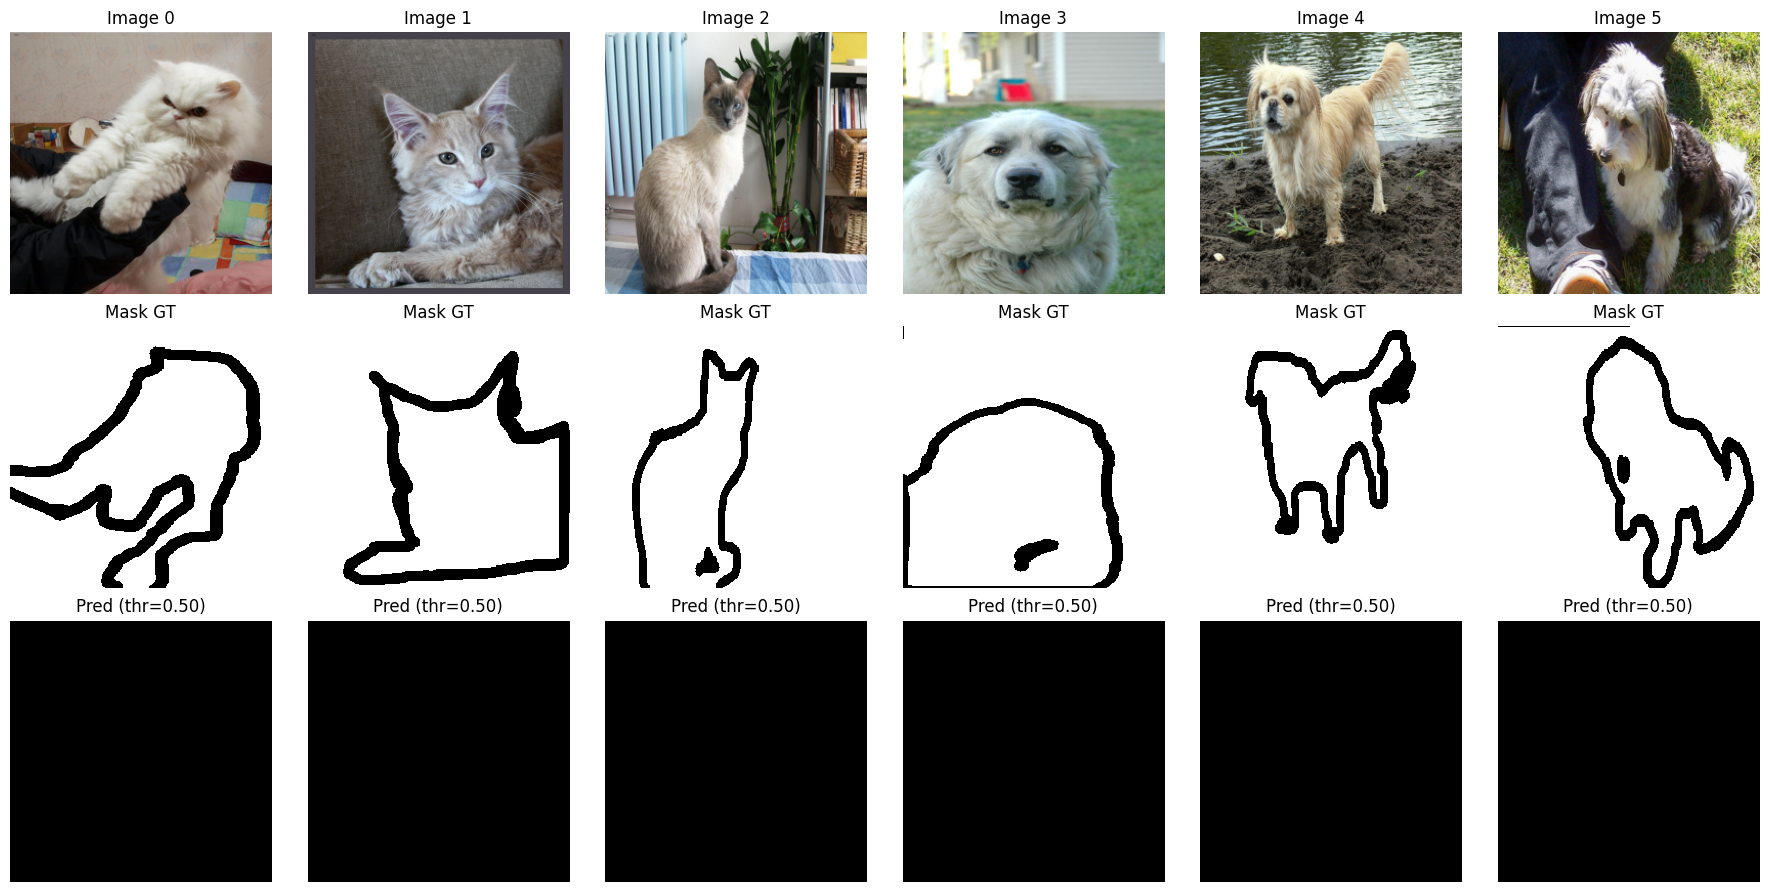

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
show_grid_img_gt_pred(model, val_loader, device, n=6, thr=0.5, save_path="grid_img_gt_pred.png")

Choisissez deux fichiers (ex. weights_epoch_3.pth et weights_epoch_10.pth).
Chargez chacun, calculez Dice/IoU (val), et affichez une grille Image/GT/Pred.
Commentez en 3–4 lignes (bords plus nets ? trous ? débordements ?).

In [ ]:
from pathlib import Path
import re, csv
import matplotlib.pyplot as plt

# SNAP_DIR = Path("./snapshots_unet_pets")

def list_snaps_sorted(snap_dir=SNAP_DIR):
    files = list(snap_dir.glob("weights_epoch_*.pth"))
    def epoch_num(p):
        m = re.search(r'epoch_(\d+)', p.name)
        return int(m.group(1)) if m else float('inf')
    files.sort(key=epoch_num)
    if (snap_dir / "best.pt").exists():
        files.append(snap_dir / "best.pt")
    return files

# metrics = []
# for snap in list_snaps_sorted():
#     load_snapshot_into_model(model, snap, device)
#     dice, iou = eval_dice_iou(model, val_loader, device, thr=0.5)
#     print(f"{snap.name:>20s}  | Dice={dice:.3f}  IoU={iou:.3f}")
#     m = re.search(r'epoch_(\d+)', snap.name)
#     epoch = int(m.group(1)) if m else None
#     metrics.append({"name": snap.name, "epoch": epoch, "dice": dice, "iou": iou})

# with open(SNAP_DIR/"snap_eval.csv", "w", newline="") as f:
#     w = csv.DictWriter(f, fieldnames=["name","epoch","dice","iou"])
#     w.writeheader(); w.writerows(metrics)

# E = [m["epoch"] for m in metrics if m["epoch"] is not None]
# D = [m["dice"]  for m in metrics if m["epoch"] is not None]
# I = [m["iou"]   for m in metrics if m["epoch"] is not None]
# plt.figure(figsize=(6,4))
# plt.plot(E, D, marker="o", label="Dice")
# plt.plot(E, I, marker="s", label="IoU")
# best = next((m for m in metrics if m["epoch"] is None), None)
# if best: plt.axhline(best["dice"], ls="--", label=f"best Dice={best['dice']:.3f}")
# plt.xlabel("epoch"); plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()


 weights_epoch_1.pth  | Dice=0.938  IoU=0.883


KeyboardInterrupt: 

weights_epoch_3.pth | Dice=0.944 | IoU=0.894


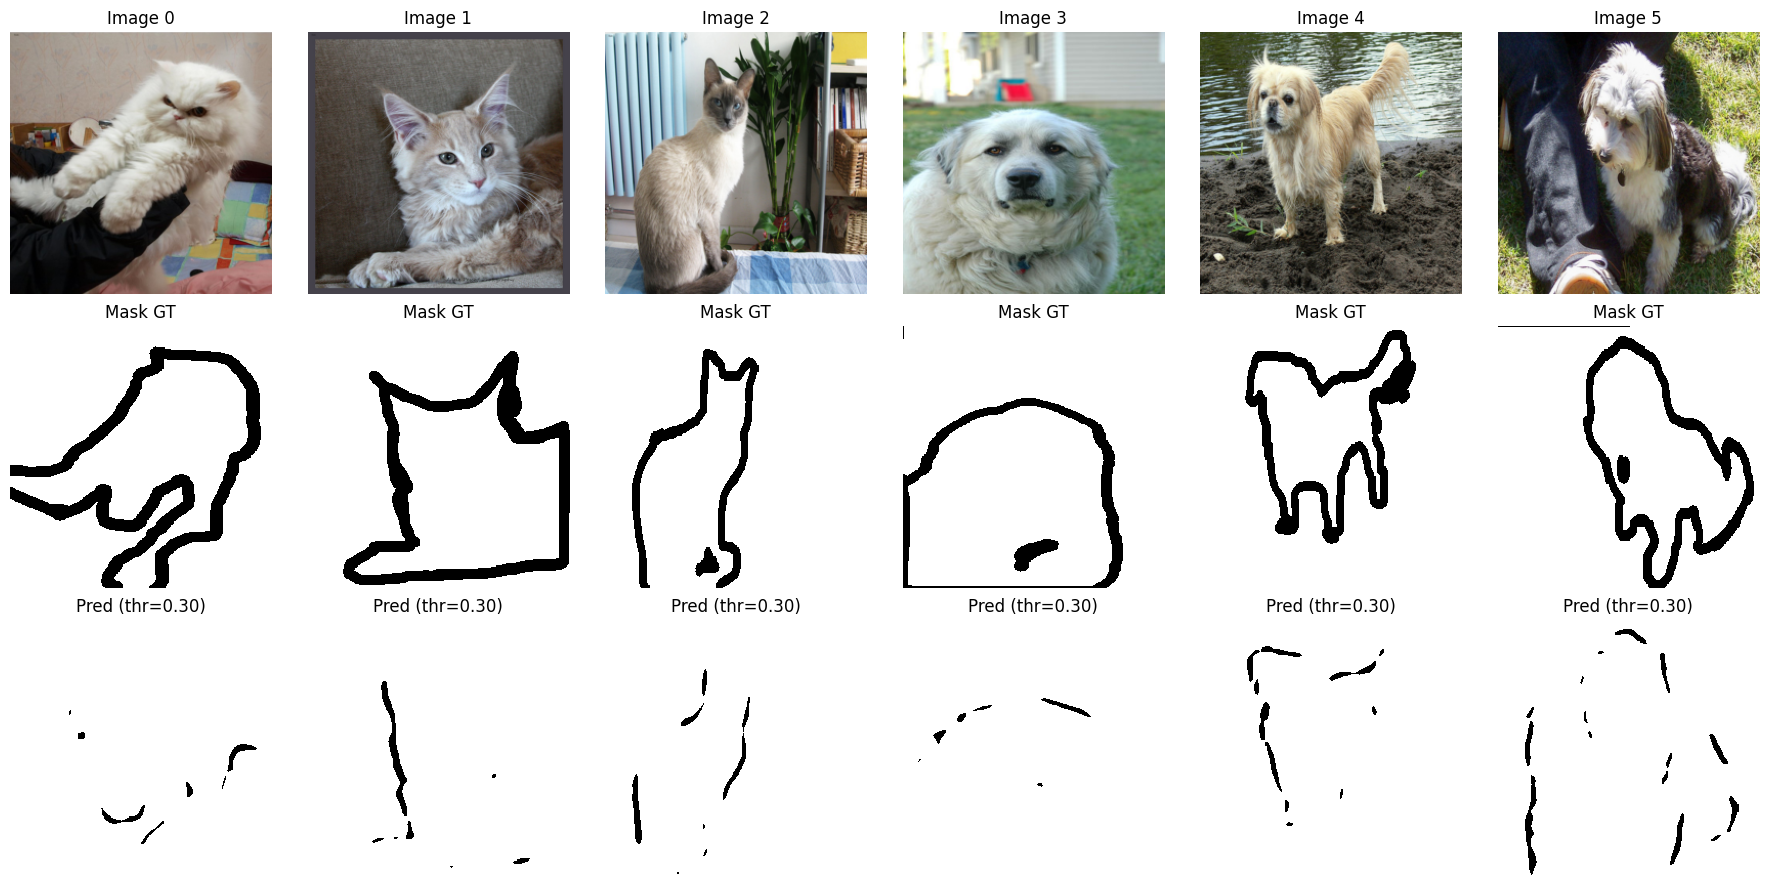

weights_epoch_10.pth | Dice=0.953 | IoU=0.909


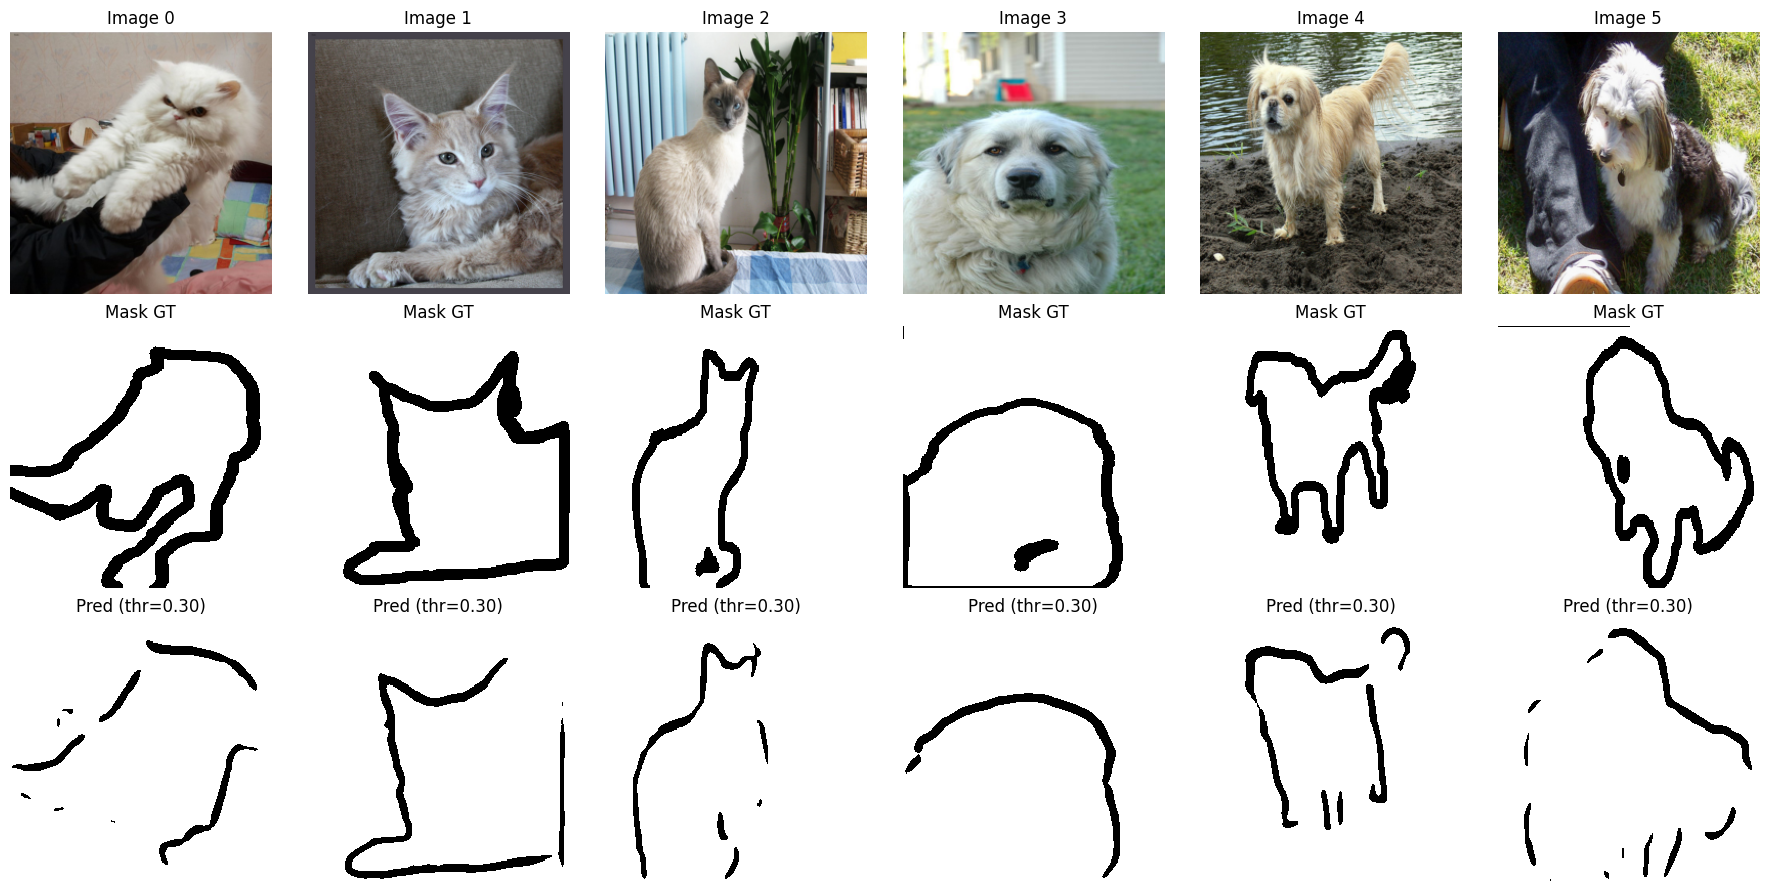

weights_epoch_3.pth | Dice=0.946 | IoU=0.898


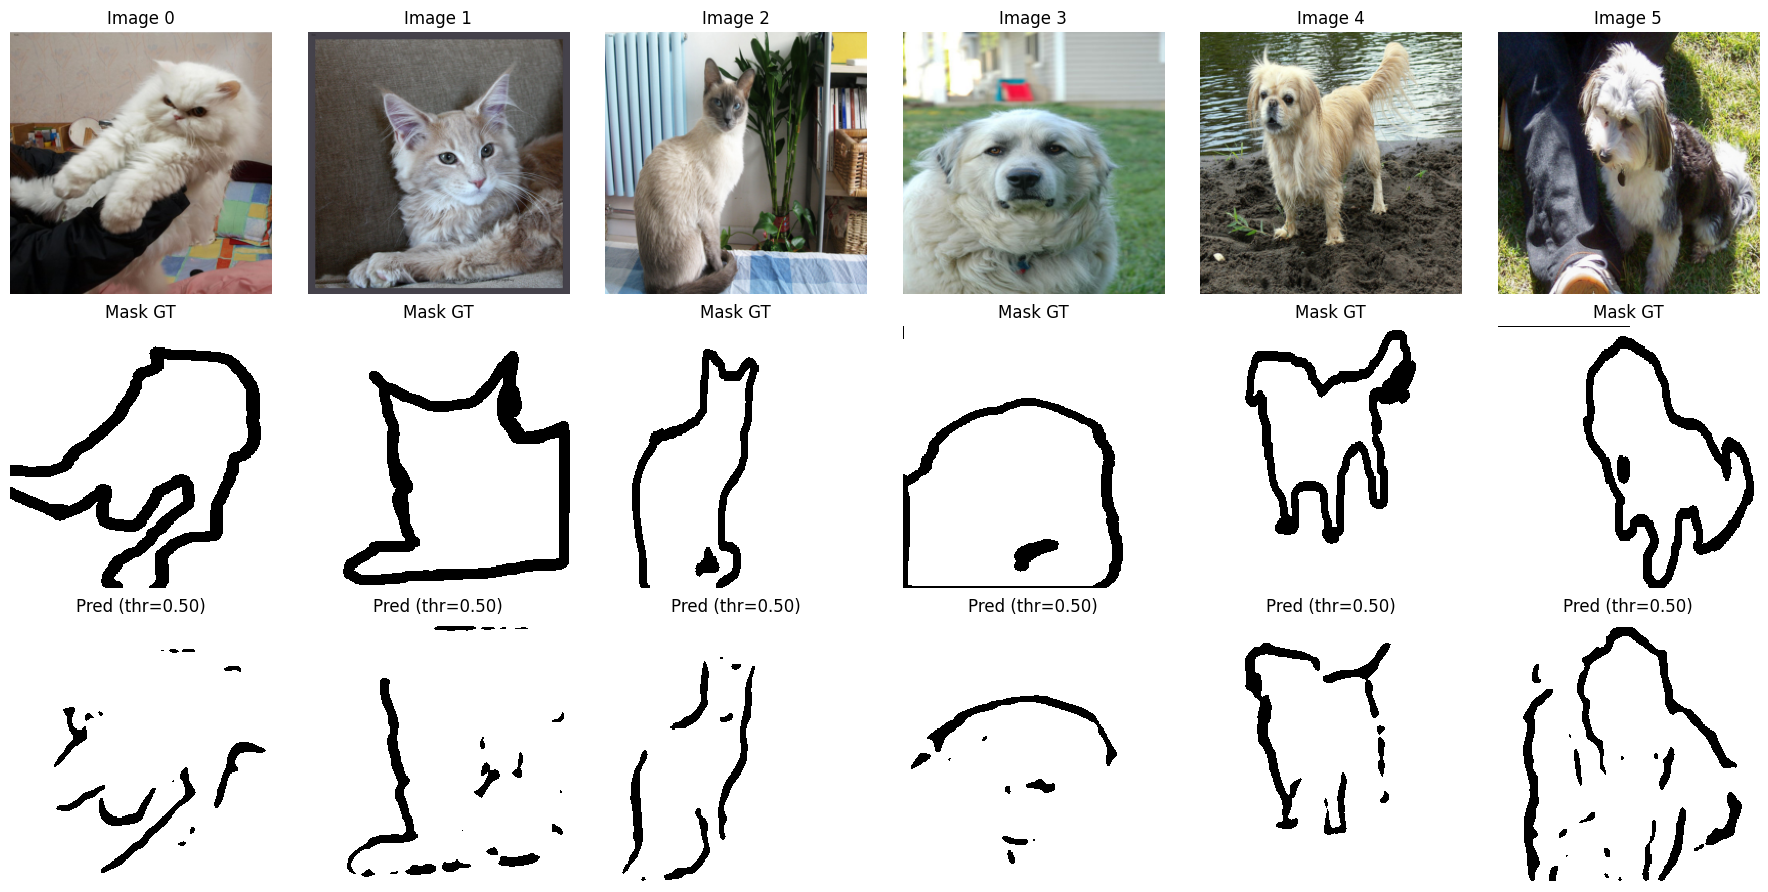

weights_epoch_10.pth | Dice=0.955 | IoU=0.913


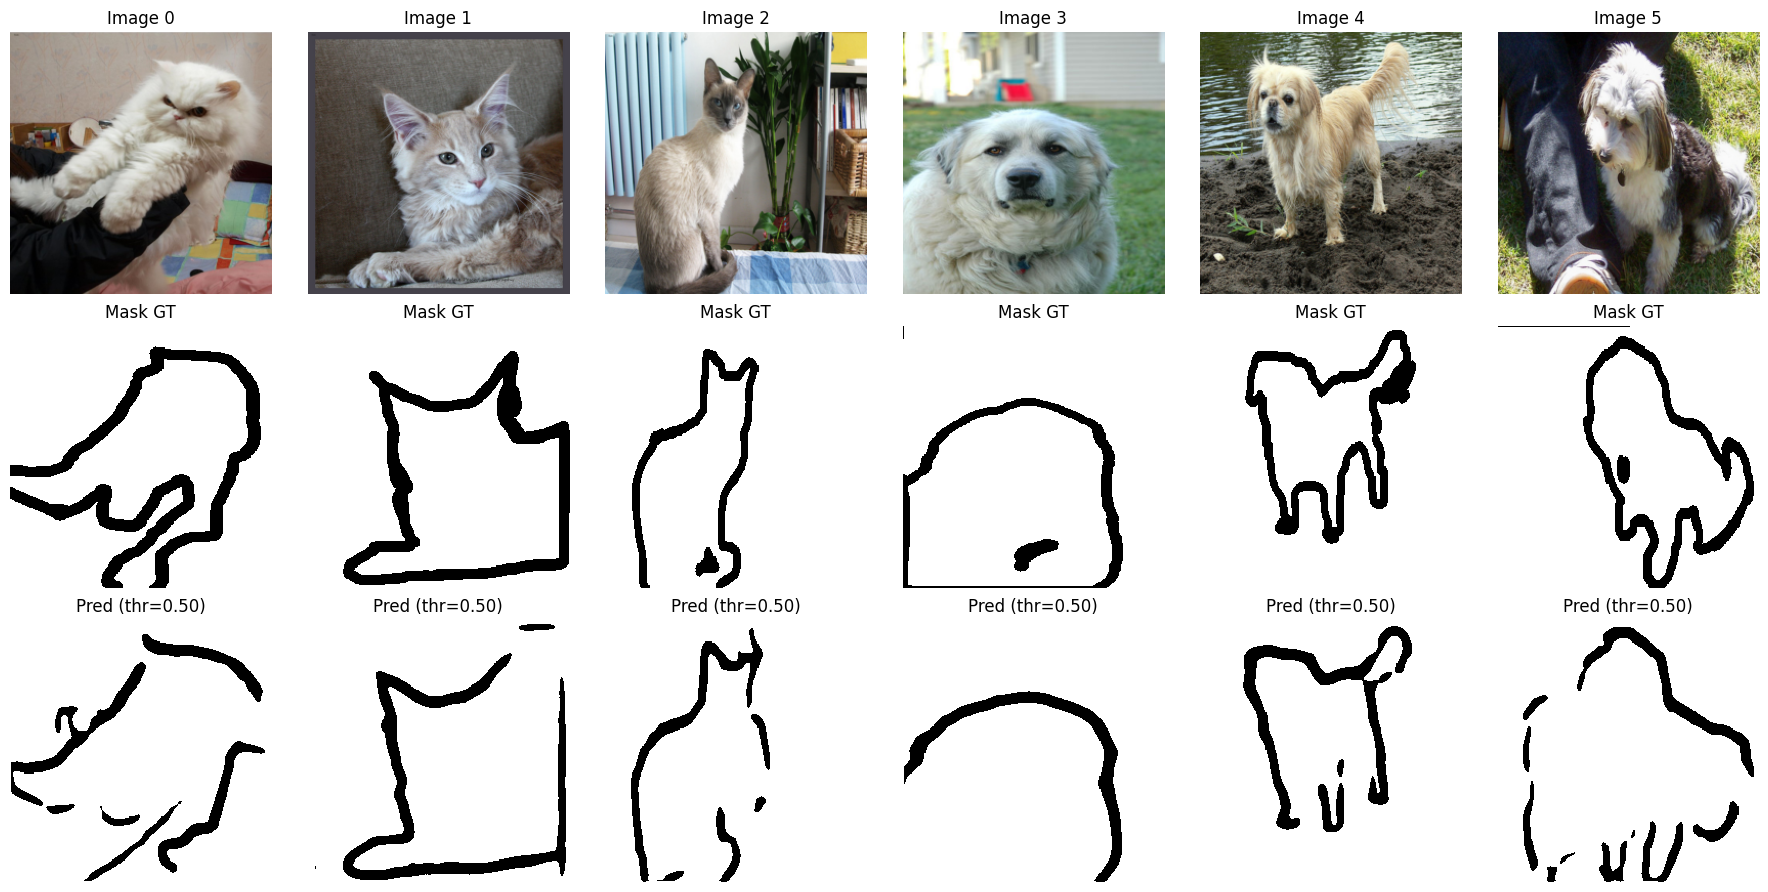

weights_epoch_3.pth | Dice=0.933 | IoU=0.874


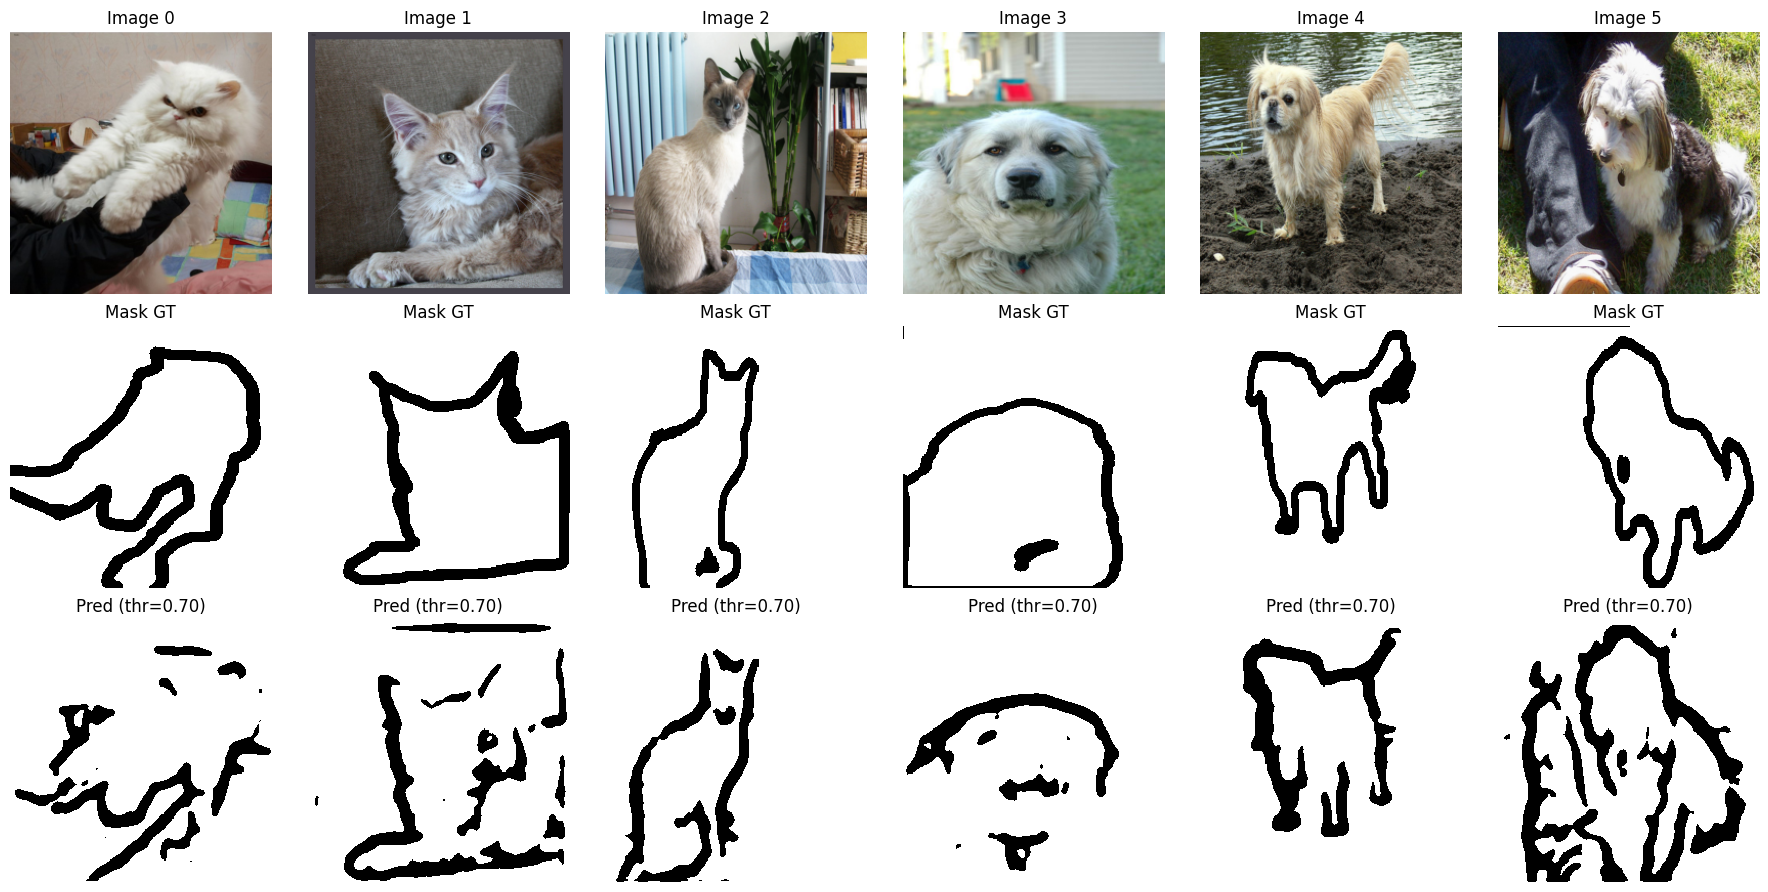

weights_epoch_10.pth | Dice=0.947 | IoU=0.899


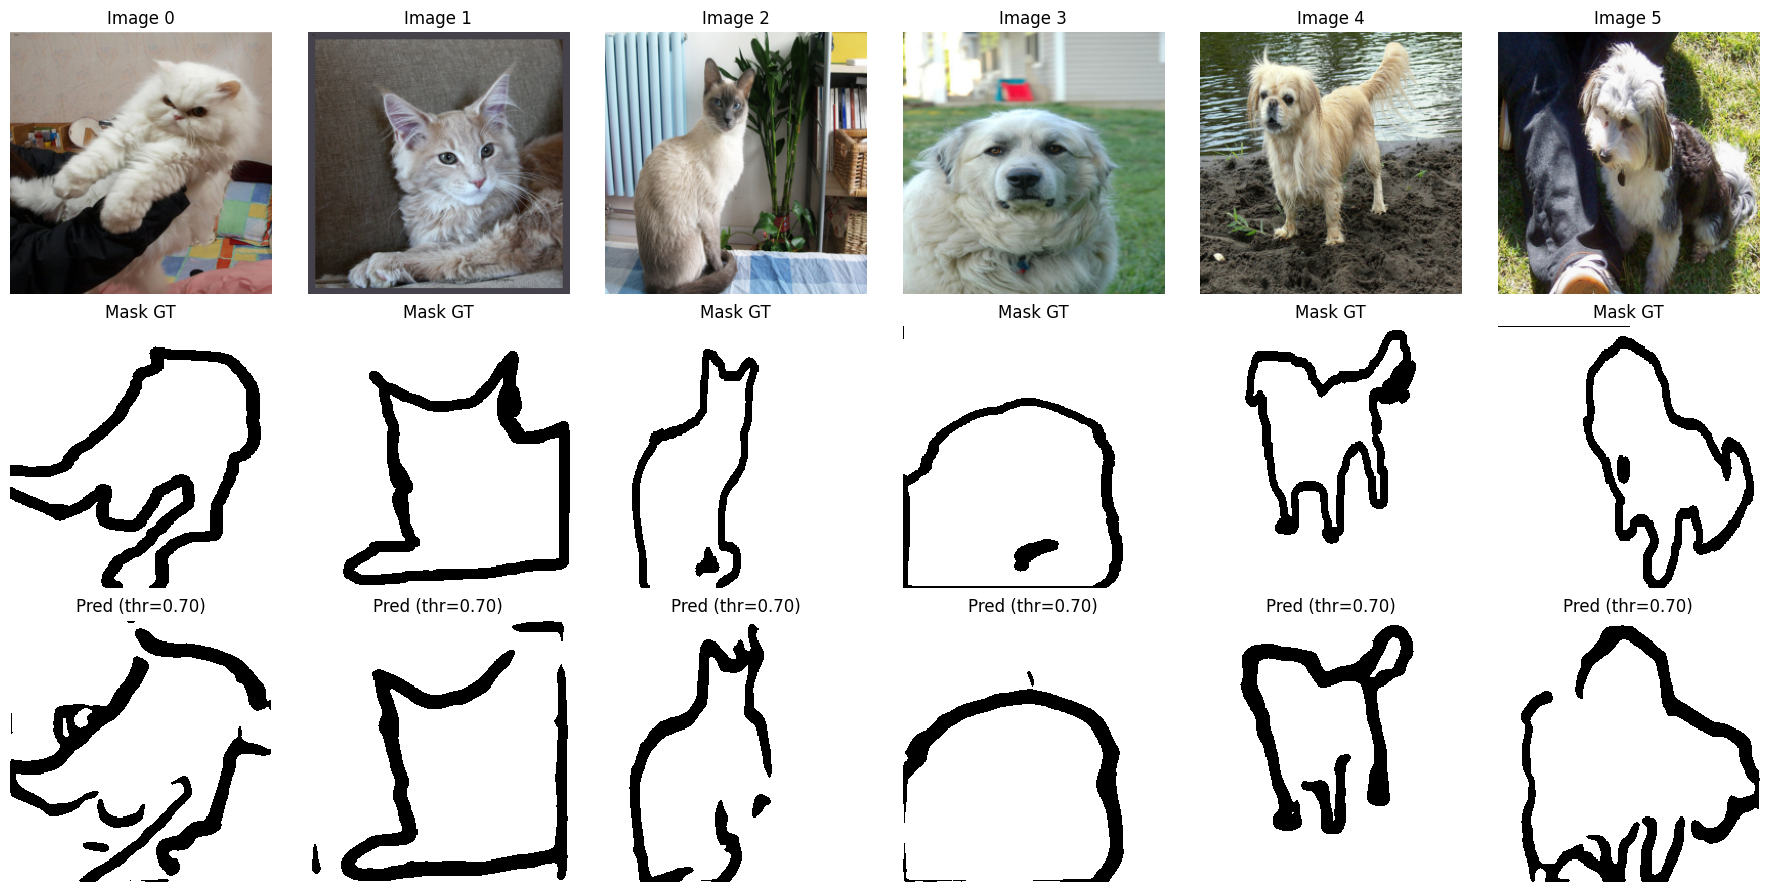

In [ ]:
model = UNetMini(in_c=3, out_c=1, base=BASE_CHANNELS).to(device)

snapA = SNAP_DIR/"weights_epoch_3.pth"
snapB = SNAP_DIR/"weights_epoch_10.pth"


# THR = 0.5

# # A
# load_snapshot_into_model(model, snapA, device)
# diceA, iouA = eval_dice_iou(model, val_loader, device, thr=THR)
# print(f"{snapA.name} | Dice={diceA:.3f} | IoU={iouA:.3f}")
# show_grid_img_gt_pred(model, val_loader, device, n=6, thr=THR)

# # B
# load_snapshot_into_model(model, snapB, device)
# diceB, iouB = eval_dice_iou(model, val_loader, device, thr=THR)
# print(f"{snapB.name} | Dice={diceB:.3f} | IoU={iouB:.3f}")
# show_grid_img_gt_pred(model, val_loader, device, n=6, thr=THR)

# À epoch 3, les prédictions sont encore grossières : les contours de l’objet sont flous 
# et certaines zones internes restent non segmentées (faux négatifs).
# À epoch 10, le masque est plus précis : les bords sont mieux définis et la surface de l’objet
# correspond mieux au masque réel, ce qui se traduit par une hausse du Dice et de l’IoU.
# On observe donc une amélioration nette de la localisation des objets grâce à l’apprentissage
# progressif des motifs et contours dans les couches profondes du U-Net.


THRs = [0.3, 0.5, 0.7]


for THR in THRs:
    # A
    load_snapshot_into_model(model, snapA, device)
    diceA, iouA = eval_dice_iou(model, val_loader, device, thr=THR)
    print(f"{snapA.name} | Dice={diceA:.3f} | IoU={iouA:.3f}")
    show_grid_img_gt_pred(model, val_loader, device, n=6, thr=THR)

    # B
    load_snapshot_into_model(model, snapB, device)
    diceB, iouB = eval_dice_iou(model, val_loader, device, thr=THR)
    print(f"{snapB.name} | Dice={diceB:.3f} | IoU={iouB:.3f}")
    show_grid_img_gt_pred(model, val_loader, device, n=6, thr=THR)


# À THR = 0.3, le modèle devient trop strict : certaines parties de l’objet disparaissent
# (augmentation des FN et masques “troués”).
# À THR = 0.5, le compromis est bon : les contours sont globalement corrects et le masque
# correspond bien à la zone réelle (équilibre entre FP et FN).
# À THR = 0.7, le modèle est trop permissif : le masque déborde sur le fond (beaucoup de FP).
# Le choix du seuil influe directement sur le compromis précision / rappel du modèle.


# Cas d'echec 1 : zones fines (ex: queue, pattes, contours fins)
# Le modèle a du mal à segmenter correctement les zones très étroites,
# souvent à cause de la perte d’information spatiale lors du pooling.

# Cas d'echec 2 : fond visuellement similaire à l’objet
# Lorsque la texture ou la couleur du fond ressemble à celle de l’objet,
# le modèle confond les deux régions et produit des débordements (FP).
